<a href="https://colab.research.google.com/github/NikethnaSri-AI/ai-learning-notebooks/blob/main/dpo_fine_tuning_prac.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%pip install -q trl==0.11.4 peft==0.14.0 datasets==3.2.0 transformers==4.45.2 rich==13.7.1

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
timm 1.0.28 requires torchvision, which is not installed.
fastai 2.8.7 requires torchvision>=0.11, which is not installed.


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from peft import LoraConfig
from transformers import (AutoModelForCausalLM, GPT2Tokenizer, set_seed, GenerationConfig)
from trl import DPOConfig, DPOTrainer

### Model and Tokenizer Setup

In [24]:
model = AutoModelForCausalLM.from_pretrained("gpt2")

In [5]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"
model.config.use_cache = False

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [6]:
model

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (attn): GPT2SdpaAttention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [7]:
ds = load_dataset("BarraHome/ultrafeedback_binarized")

README.md: 0.00B [00:00, ?B/s]

data/train_prefs-00000-of-00001.parquet:   0%|          | 0.00/226M [00:00<?, ?B/s]

data/test_prefs-00000-of-00001.parquet:   0%|          | 0.00/7.29M [00:00<?, ?B/s]

data/test_sft-00000-of-00001.parquet:   0%|          | 0.00/3.72M [00:00<?, ?B/s]

data/train_gen-00000-of-00001.parquet:   0%|          | 0.00/184M [00:00<?, ?B/s]

...

Generating train_sft split:   0%|          | 0/61135 [00:00<?, ? examples/s]

Generating test_prefs split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test_sft split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating train_gen split:   0%|          | 0/61135 [00:00<?, ? examples/s]

Generating test_gen split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [9]:
print("Dataset splits:")
print(ds.keys())

Dataset splits:
dict_keys(['train_prefs', 'train_sft', 'test_prefs', 'test_sft', 'train_gen', 'test_gen'])


In [10]:
ds["train_prefs"][0]

{'prompt': 'how can i develop a habit of drawing daily',
 'prompt_id': '086b3e24f29b8956a01059f79c56db35d118a06fb6b844b095737d042795cd43',
 'chosen': [{'content': 'how can i develop a habit of drawing daily',
   'role': 'user'},
  {'content': "Developing a daily habit of drawing can be challenging but with consistent practice and a few tips, it can become an enjoyable and rewarding part of your daily routine. Here are some strategies to help you develop the habit of drawing daily:\n\n1. Set a specific time: Allocate a specific time of the day to draw. It could be in the morning, afternoon, or evening. Make drawing a part of your daily routine.\n2. Set a specific duration: Determine the amount of time you want to spend on drawing each day. It can be as little as 10 minutes or as long as an hour. Be consistent with the duration to help build the habit.\n3. Start small and simple: Don't try to create a masterpiece every day, start with simple and easy-to-do sketches. Focus on improving yo

### Data Preprocessing

In [11]:
for key in ds:
    cnt = 50
    ds[key] = ds[key].select(range(cnt))

def process(row):
    del row["prompt_id"]
    del row["messages"]
    del row["score_chosen"]
    del row["score_rejected"]

    row["chosen"] = row["chosen"][-1]["content"]
    row["rejected"] = row["rejected"][-1]["content"]

    return row

ds = ds.map(
    process,
    num_proc=1,
    load_from_cache_file=False
)

train_dataset = ds["train_prefs"]
eval_dataset = ds["test_prefs"]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

In [12]:
train_dataset[0]

{'prompt': 'how can i develop a habit of drawing daily',
 'chosen': "Developing a daily habit of drawing can be challenging but with consistent practice and a few tips, it can become an enjoyable and rewarding part of your daily routine. Here are some strategies to help you develop the habit of drawing daily:\n\n1. Set a specific time: Allocate a specific time of the day to draw. It could be in the morning, afternoon, or evening. Make drawing a part of your daily routine.\n2. Set a specific duration: Determine the amount of time you want to spend on drawing each day. It can be as little as 10 minutes or as long as an hour. Be consistent with the duration to help build the habit.\n3. Start small and simple: Don't try to create a masterpiece every day, start with simple and easy-to-do sketches. Focus on improving your skills gradually.\n4. Use a variety of tools and mediums: Experiment with different tools like pencils, pens, markers, and different mediums like paper, canvas, or digital 

### LoRA configuration:

In [13]:
# PEFT (Parameter-Efficient Finetuning) configuration
peft_config = LoraConfig(
        # rank
        r=4,
        target_modules=['c_proj','c_attn'],
        task_type="CAUSAL_LM",
        lora_alpha=8,
        lora_dropout=0.1,
        bias="none",
)

### DPO configuration

In [14]:
from peft import get_peft_model
training_args = DPOConfig(
    #beta parameter is for the DPO loss function
    beta=0.1,
    output_dir="dpo",
    num_train_epochs=5,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    remove_unused_columns=False,
    logging_steps=10,
    gradient_accumulation_steps=1,
    learning_rate=1e-4,
    evaluation_strategy="epoch",
    warmup_steps=2,
    fp16=False,
    save_steps=500,
    report_to='none'
)

/root/.local/lib/python3.12/site-packages/transformers/training_args.py:1545: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


### DPO training

In [15]:
tokenizer.pad_token = tokenizer.eos_token

# Create a DPO trainer to handle the fine-tuning of the model using the DPO technique
trainer = DPOTrainer(
        model=model,
        ref_model=None,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        tokenizer=tokenizer,
        #PEFT (Parallel Efficient Finetuning) configuration
        peft_config=peft_config,
        # The maximum prompt or sequence length
        max_length=512,
    )

/root/.local/lib/python3.12/site-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': max_length. Will not be supported from version '1.0.0'.

Deprecated positional argument(s) used in DPOTrainer, please use the DPOConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/root/.local/lib/python3.12/site-packages/peft/tuners/lora/layer.py:1264: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(
/root/.local/lib/python3.12/site-packages/trl/trainer/dpo_trainer.py:655: UserWarning: You passed `max_length` to the DPOTrainer, the value you passed will override the one in the `DPOConfig`.
  warnings.warn(
/root/.local/lib/python3.12/site-packages/trl/trainer/dpo_trainer.py:673: UserWarning: `max_prompt_length` is not set in the DPOConfig's init it will default to `128` by default, but you should do it yourself in the future.
  warnings.wa

Tokenizing train dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1154 > 1024). Running this sequence through the model will result in indexing errors


Tokenizing eval dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

### Training model


In [16]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Could not estimate the number of tokens of the input, floating-point operations will not be computed


Epoch,Training Loss,Validation Loss,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/rejected,Logps/chosen,Logits/rejected,Logits/chosen
1,0.689800,0.676967,0.102570,0.063221,0.500000,0.039349,-527.958801,-536.379272,-103.791924,-103.808563
2,0.603700,0.655891,0.288478,0.161976,0.580000,0.126502,-526.971313,-534.520142,-103.949646,-104.007187
3,0.287200,0.654851,0.543302,0.309213,0.600000,0.234089,-525.498901,-531.971924,-104.162033,-104.275146
4,0.388700,0.670416,0.734731,0.425260,0.580000,0.309471,-524.338440,-530.057617,-104.251183,-104.398026
5,0.464300,0.678260,0.791632,0.459951,0.600000,0.331681,-523.991516,-529.488647,-104.314484,-104.468636


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=250, training_loss=0.4802214498519897, metrics={'train_runtime': 5874.6919, 'train_samples_per_second': 0.043, 'train_steps_per_second': 0.043, 'total_flos': 0.0, 'train_loss': 0.4802214498519897, 'epoch': 5.0})

In [18]:
print(hasattr(model, "generate"))

True


### Evaluating the model

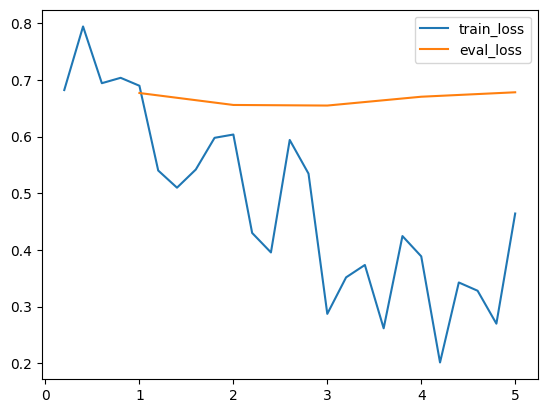

In [21]:
log = pd.DataFrame(trainer.state.log_history)
log_t = log[log['loss'].notna()]
log_e = log[log['eval_loss'].notna()]

# Plotting train and evaluation losses
plt.plot(log_t["epoch"], log_t["loss"], label = "train_loss")
plt.plot(log_e["epoch"], log_e["eval_loss"], label = "eval_loss")
plt.legend()
plt.show()

In [26]:
dpo_model = trainer.model
dpo_model.eval()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): GPT2LMHeadModel(
      (transformer): GPT2Model(
        (wte): Embedding(50257, 768)
        (wpe): Embedding(1024, 768)
        (drop): Dropout(p=0, inplace=False)
        (h): ModuleList(
          (0-11): 12 x GPT2Block(
            (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
            (attn): GPT2SdpaAttention(
              (c_attn): lora.Linear(
                (base_layer): Conv1D(nf=2304, nx=768)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=768, out_features=4, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=4, out_features=2304, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()


### Testing with a Sample Prompt

In [27]:
set_seed(42)

generation_config = GenerationConfig(
    do_sample=True,
    top_k=1,
    temperature=0.1,
    max_new_tokens=40,
    pad_token_id=tokenizer.eos_token_id
)

PROMPT = "How can I learn Python as a beginner?"

inputs = tokenizer(PROMPT, return_tensors="pt")

outputs = dpo_model.generate(
    **inputs,
    generation_config=generation_config
)

print("DPO response:")
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

DPO response:
How can I learn Python as a beginner?

Python is a programming language that is easy to learn and understand. It is a language that is easy to learn and understand. It is a language that is easy to learn and understand. It


### Comparing against normal GPT-2

In [28]:
gpt2_model = AutoModelForCausalLM.from_pretrained("gpt2")

outputs = gpt2_model.generate(
    **inputs,
    generation_config=generation_config
)

print("GPT-2 response:")
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

GPT-2 response:
How can I learn Python as a beginner?

Python is a programming language that is easy to learn and understand. It is a language that is easy to learn and understand. It is a language that is easy to learn and understand. It


Result Observation:

The base GPT-2 response became repetitive, which was interesting to compare with the DPO-tuned response.